# Explorer les tables NeonDB

Objectif : se connecter à NeonDB depuis le `.env`, vérifier les tables disponibles, puis afficher un aperçu (`head`) de chaque table du projet Foot Predictor.

Le notebook ne modifie aucune donnée : il fait uniquement des lectures SQL.


## 1. Setup

Le notebook cherche une URL de connexion dans `NEON_DATABASE_URL`, `DATABASE_URL` ou `POSTGRES_URL`.


In [118]:
from pathlib import Path
import os

import pandas as pd
from sqlalchemy import create_engine, text
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 50)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / ".env").exists():
    raise FileNotFoundError("Fichier .env introuvable dans foot-predictor.")

SCHEMA = "public"
TABLES = ["competition", "team", "player", "match", "match_team", "lineup", "lineup_audit"]
HEAD_ROWS = 5


## 2. Charger la connexion Neon

On lit le `.env` sans afficher la valeur de connexion.


In [121]:
def load_env_file(path: Path) -> dict[str, str]:
    values = {}
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


def sqlalchemy_url(url: str) -> str:
    if url.startswith("postgres://"):
        return url.replace("postgres://", "postgresql+psycopg2://", 1)
    if url.startswith("postgresql://"):
        return url.replace("postgresql://", "postgresql+psycopg2://", 1)
    return url

local_env = load_env_file(PROJECT_ROOT / ".env")
DATABASE_URL = (
    os.environ.get("NEON_DATABASE_URL")
    or os.environ.get("DATABASE_URL")
    or os.environ.get("POSTGRES_URL")
    or local_env.get("NEON_DATABASE_URL")
    or local_env.get("DATABASE_URL")
    or local_env.get("POSTGRES_URL")
    or ""
)

if not DATABASE_URL:
    raise RuntimeError("Ajoute NEON_DATABASE_URL, DATABASE_URL ou POSTGRES_URL dans .env.")

engine = create_engine(sqlalchemy_url(DATABASE_URL), pool_pre_ping=True)
print("Connexion configuree :", bool(DATABASE_URL))


Connexion configuree : True


## 3. Résumé des tables

On vérifie le nombre de lignes et de colonnes avant les aperçus.


In [ ]:
summary_rows = []

with engine.begin() as connection:
    for table_name in TABLES:
        row_count = connection.execute(
            text(f'SELECT COUNT(*) FROM "{SCHEMA}"."{table_name}"')
        ).scalar_one()
        column_count = connection.execute(
            text("""
                SELECT COUNT(*)
                FROM information_schema.columns
                WHERE table_schema = :schema
                  AND table_name = :table_name
            """),
            {"schema": SCHEMA, "table_name": table_name},
        ).scalar_one()
        summary_rows.append({"table": table_name, "rows": row_count, "columns": column_count})

tables_summary = pd.DataFrame(summary_rows)
display(tables_summary)


## 4. Aperçu de chaque table

Chaque bloc charge seulement quelques lignes avec `LIMIT`, pas toute la table.


In [ ]:
heads = {}

for table_name in TABLES:
    query = f'SELECT * FROM "{SCHEMA}"."{table_name}" LIMIT {HEAD_ROWS}'
    heads[table_name] = pd.read_sql(query, engine)
    print(f"\n{table_name}")
    display(heads[table_name])


## 5. Exemple de jointure "simple"

Petit aperçu optionnel pour vérifier que `lineup` rejoint bien `match`, `team` et `player`.


In [ ]:
lineup_preview_query = f'''
SELECT
    l.match_id,
    m.match_date,
    ht.team_name AS home_team,
    at.team_name AS away_team,
    t.team_name AS lineup_team,
    mt.side,
    mt.score,
    mt.manager_name,
    mt.formation,
    l.lineup_type,
    l.position_player,
    l.minute_start,
    l.minute_end,
    l.minutes_played,
    l.player_id,
    p.player_name,
    p.sofifa_name,
    p.has_sofifa_profile
FROM "{SCHEMA}"."lineup" l
LEFT JOIN "{SCHEMA}"."match" m ON m.match_id = l.match_id
LEFT JOIN "{SCHEMA}"."match_team" mt ON mt.match_id = l.match_id AND mt.team_id = l.team_id
LEFT JOIN "{SCHEMA}"."team" t ON t.team_id = l.team_id
LEFT JOIN "{SCHEMA}"."match_team" hm ON hm.match_id = l.match_id AND hm.side = 'home'
LEFT JOIN "{SCHEMA}"."team" ht ON ht.team_id = hm.team_id
LEFT JOIN "{SCHEMA}"."match_team" am ON am.match_id = l.match_id AND am.side = 'away'
LEFT JOIN "{SCHEMA}"."team" at ON at.team_id = am.team_id
LEFT JOIN "{SCHEMA}"."player" p ON p.player_id = l.player_id
ORDER BY m.match_date DESC, l.match_id, mt.side, l.lineup_type, p.player_name
LIMIT {HEAD_ROWS * 4}
'''

display(pd.read_sql(lineup_preview_query, engine))

## Check des features descriptives des joueurs

In [ ]:
# Création d'un dataframe
players_df = pd.read_sql(f'SELECT * FROM "{SCHEMA}"."player"', engine)

print(players_df.shape)
display(players_df.head())

### Features agrégées SoFIFA

On calcule une version simple des sept groupes visibles sur SoFIFA à partir des caractéristiques détaillées déjà présentes dans `players_df`.

In [ ]:
# Agrégation simple des caractéristiques SoFIFA par joueur.
# Chaque groupe est la moyenne des notes détaillées visibles dans la capture SoFIFA.

sofifa_feature_groups = {
    "vit": ["sprint_speed", "acceleration"],
    "tir": ["finishing", "attack_position", "shot_power", "long_shots", "penalties", "volleys"],
    "pas": ["vision", "crossing", "fk_accuracy", "long_passing", "short_passing", "curve"],
    "dri": ["agility", "balance", "reactions", "composure", "ball_control", "dribbling"],
    "defense": ["interceptions", "heading_accuracy", "defensive_awareness", "standing_tackle", "sliding_tackle"],
    "phy": ["jumping", "stamina", "strength", "aggression"],
    "gardien": ["gk_diving", "gk_handling", "gk_kicking", "gk_positioning", "gk_reflexes"],
}

identity_columns = [
    "player_id",
    "player_name",
    "sofifa_name",
    "best_position",
    "observed_positions",
]

sofifa_detail_columns = sorted({
    column
    for columns in sofifa_feature_groups.values()
    for column in columns
})

missing_columns = [
    column
    for column in identity_columns + sofifa_detail_columns
    if column not in players_df.columns
]

if missing_columns:
    raise KeyError(f"Colonnes absentes de players_df: {missing_columns}")

players_with_sofifa_df = players_df.copy()

if "has_sofifa_profile" in players_with_sofifa_df.columns:
    has_sofifa_profile = (
        players_with_sofifa_df["has_sofifa_profile"]
        .fillna(0)
        .astype(str)
        .str.lower()
        .isin(["1", "1.0", "true", "yes"])
    )
    players_with_sofifa_df = players_with_sofifa_df[has_sofifa_profile].copy()

numeric_sofifa_features = players_with_sofifa_df[sofifa_detail_columns].apply(pd.to_numeric, errors="coerce")

for group_name, source_columns in sofifa_feature_groups.items():
    players_with_sofifa_df[group_name] = numeric_sofifa_features[source_columns].mean(axis=1).round(1)

aggregate_columns = list(sofifa_feature_groups.keys())

player_aggregate_features_df = (
    players_with_sofifa_df[identity_columns + aggregate_columns]
    .dropna(subset=aggregate_columns, how="all")
    .sort_values(["best_position", "player_name"], na_position="last")
    .reset_index(drop=True)
)

print(player_aggregate_features_df.shape)
display(player_aggregate_features_df.head(10))
print(player_aggregate_features_df.count())

In [ ]:
# Note globale simple hors gardien.
# On exclut `gardien` ici pour garder une note comparable entre joueurs de champ.
columns_note = ["vit", "tir", "pas", "dri", "defense", "phy"]

player_aggregate_features_df["global_note"] = (
    player_aggregate_features_df[columns_note]
    .mean(axis=1)
    .round(1)
)

print(player_aggregate_features_df.shape)
display(player_aggregate_features_df.head(10))

### Jeu d'entrainement minimal

Une ligne par match : `match_id`, les notes globales des 22 titulaires, puis `target_result`.

In [ ]:
# Objectif : construire un dataset minimal pour entrainer un modèle.
# Une ligne = un match.
# Colonnes finales = match_id + 22 notes de titulaires + target_result.

# 1. On récupère les scores par équipe et les joueurs présents dans les lineups.
match_team_df = pd.read_sql(
    f'''
    SELECT match_id, team_id, side, score
    FROM "{SCHEMA}"."match_team"
    ''',
    engine,
)

lineup_df = pd.read_sql(
    f'''
    SELECT match_id, team_id, player_id, is_starting_match
    FROM "{SCHEMA}"."lineup"
    ''',
    engine,
)

# 2. On définit team 1 = équipe à domicile, team 2 = équipe extérieure.
team_1_df = (
    match_team_df[match_team_df["side"] == "home"]
    .rename(columns={"team_id": "team_1_id", "score": "team_1_score"})
    [["match_id", "team_1_id", "team_1_score"]]
)

team_2_df = (
    match_team_df[match_team_df["side"] == "away"]
    .rename(columns={"team_id": "team_2_id", "score": "team_2_score"})
    [["match_id", "team_2_id", "team_2_score"]]
)

# 3. On calcule le résultat du match du point de vue de team 1.
match_result_df = team_1_df.merge(team_2_df, on="match_id", how="inner")
match_result_df["team_1_score"] = pd.to_numeric(match_result_df["team_1_score"], errors="coerce")
match_result_df["team_2_score"] = pd.to_numeric(match_result_df["team_2_score"], errors="coerce")

match_result_df["target_result"] = 0
match_result_df.loc[match_result_df["team_1_score"] > match_result_df["team_2_score"], "target_result"] = 1
match_result_df.loc[match_result_df["team_1_score"] < match_result_df["team_2_score"], "target_result"] = -1

# 4. On récupère uniquement la note globale de chaque joueur.
player_notes_df = player_aggregate_features_df[["player_id", "global_note"]].copy()

# 5. On garde seulement les titulaires et on leur ajoute leur note globale.
lineup_notes_df = (
    lineup_df[lineup_df["is_starting_match"].fillna(0).astype(int) == 1]
    .merge(player_notes_df, on="player_id", how="left")
    .merge(match_result_df[["match_id", "team_1_id", "team_2_id"]], on="match_id", how="inner")
)

# 6. On indique si chaque joueur appartient à team 1 ou team 2.
lineup_notes_df["team_number"] = 2
lineup_notes_df.loc[lineup_notes_df["team_id"] == lineup_notes_df["team_1_id"], "team_number"] = 1

# 7. On numérote simplement les 11 titulaires de chaque équipe.
lineup_notes_df = lineup_notes_df.sort_values(["match_id", "team_number", "player_id"])
lineup_notes_df["player_number"] = lineup_notes_df.groupby(["match_id", "team_number"]).cumcount() + 1
lineup_notes_df = lineup_notes_df[lineup_notes_df["player_number"] <= 11]

# 8. On passe d'un format long à un format large : une ligne par match.
players_notes_wide_df = (
    lineup_notes_df
    .pivot_table(
        index="match_id",
        columns=["team_number", "player_number"],
        values="global_note",
        aggfunc="first",
    )
)

players_notes_wide_df.columns = [
    f"team_{team_number}_player_{player_number}_note"
    for team_number, player_number in players_notes_wide_df.columns
]

players_notes_wide_df = players_notes_wide_df.reset_index()

# 9. Dataset final : match_id + notes joueurs + target_result.
training_dataset_df = (
    match_result_df[["match_id", "target_result"]]
    .merge(players_notes_wide_df, on="match_id", how="inner")
)

# 10. On garde seulement les matchs où les 22 titulaires ont une note disponible.
note_columns = [column for column in training_dataset_df.columns if column.endswith("_note")]
training_dataset_df = training_dataset_df.dropna(subset=note_columns).reset_index(drop=True)

training_dataset_df = training_dataset_df[["match_id"] + note_columns + ["target_result"]]

print(training_dataset_df.shape)
display(training_dataset_df.head())

In [ ]:
match_result_df


In [ ]:
training_dataset_df.to_csv(
    'training_dataset.csv',
    index=False,      # ne pas écrire l'index
    sep=';',          # séparateur ; (souvent utilisé en France)
    encoding='utf-8'  # encodage
)

In [92]:
from sklearn.model_selection import train_test_split

X = training_dataset_df.drop(["target_result","match_id"], axis=1)
y = training_dataset_df["target_result"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.2, stratify=y)


In [ ]:
X_train

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

In [ ]:
# Perform grid search
print("Grid search...")
classifier = RandomForestClassifier(class_weight="balanced")

# Grid of values to be tested
params = {
    "max_depth": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 4, 8],
    "n_estimators": [10, 20, 40, 60, 80, 100]

}
gridsearch = GridSearchCV(
    classifier, param_grid=params, 
    # scoring={
    #     'accuracy': 'accuracy',
    #     'f1': 'f1',
    #     'precision': 'precision',
    #     'recall': 'recall'
    # },
    # refit='accuracy', # métrique utilisée pour sélectionner le meilleur modèle
    cv=5 # cv : the number of folds to be used for CV
)  
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)

In [ ]:
best_model = gridsearch.best_estimator_

print("R² train :", gridsearch.score(X_train, y_train))
print("R² test  :", gridsearch.score(X_test, y_test))

In [ ]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = gridsearch.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on training set...")
Y_train_proba = gridsearch.predict_proba(X_train)
print("...Done.")
print(Y_train_proba)
print()

# Predictions on test set
print("Predictions on test set...")
Y_test_pred = gridsearch.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on test set...")
Y_test_proba = gridsearch.predict_proba(X_test)
print("...Done.")
print(Y_test_proba)
print()


In [93]:
from sklearn.metrics import accuracy_score

y_test_pred = gridsearch.predict(X_test)

acc = accuracy_score(y_test, y_test_pred)

print(acc)

0.45545977011494254


In [ ]:
y_test_df=pd.DataFrame({
    "y_test": y_test,
    "y_test_pred": y_test_pred 
})

y_test_df.reset_index(drop=True, inplace=True)
y_test_df["is_prediction_correct"] = y_test_df["y_test"] == y_test_df["y_test_pred"]
y_test_df.groupby(['y_test', 'is_prediction_correct']).size()

In [ ]:
y_test_df.groupby(['y_test', 'is_prediction_correct']).size()

3 classes de résultat
- comment elles sont réparties ?
- predir au pif - dummy classifier - est-ce qu'on est plus fort qu'un dummy ?
- sortir la matrice de confusion et interpréter

1. Comment sont réparties les 3 classes ?

In [ ]:
y_test_df=pd.DataFrame({
    "y_test": y_test,
    "y_test_pred": y_test_pred 
})

y_test_df.reset_index(drop=True, inplace=True)
y_test_df["is_prediction_correct"] = y_test_df["y_test"] == y_test_df["y_test_pred"]
y_test_df.groupby(['y_test', 'is_prediction_correct']).size()

In [ ]:
print(y.value_counts())
print()
print(y.value_counts()/len(y))


3. Matrice de confusion

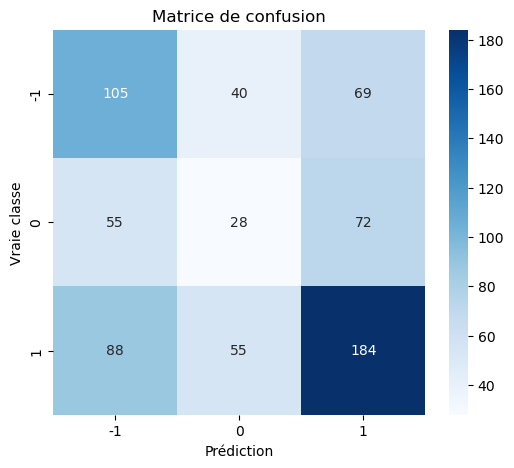

In [88]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred, labels=[-1, 0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[-1, 0, 1],
    yticklabels=[-1, 0, 1]
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion")
plt.show()

2. predir au pif - dummy classifier - est-ce qu'on est plus fort qu'un dummy ?

2.1 dummy - most-frequent

In [89]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_test_dummy_pred = dummy.predict(X_test)

acc_dummy_most_frequent = accuracy_score(y_test, y_test_dummy_pred)

print("Accuracy of the dummy classifier (most frequent):", acc_dummy_most_frequent)


Accuracy of the dummy classifier (most frequent): 0.4698275862068966


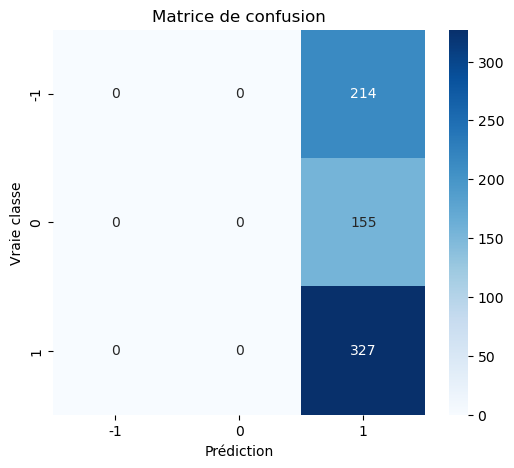

In [90]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_dummy_most_frequent = confusion_matrix(y_test, y_test_dummy_pred, labels=[-1, 0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dummy_most_frequent,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[-1, 0, 1],
    yticklabels=[-1, 0, 1]
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion")
plt.show()

2.1 dummy - stratified

In [91]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="stratified")
dummy.fit(X_train, y_train)
y_test_dummy_pred = dummy.predict(X_test)

acc_dummy_stratified = accuracy_score(y_test, y_test_dummy_pred)

print("Accuracy of the dummy classifier (stratified):", acc_dummy_stratified)

Accuracy of the dummy classifier (stratified): 0.3620689655172414


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_dummy_most_frequent = confusion_matrix(y_test, y_test_dummy_pred, labels=[-1, 0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dummy_most_frequent,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[-1, 0, 1],
    yticklabels=[-1, 0, 1]
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion")
plt.show()

algo XGBoost 

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_boost = le.fit_transform(y)

In [ ]:
y_boost

In [ ]:
X_train_boost, X_test_boost, y_train_boost, y_test_boost = train_test_split(X, y_boost, random_state=0, test_size=0.2, stratify=y)

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weight = compute_sample_weight(
    class_weight='balanced',
    y=y_train_boost
)

In [82]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

# Modèle
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

# Hyperparamètres à tester
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Grid Search
grid_boost = GridSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_boost.fit(X_train_boost, y_train_boost, sample_weight=sample_weight)

print("Meilleurs paramètres :", grid_boost.best_params_)
print("Meilleure accuracy CV :", grid_boost.best_score_)

Meilleurs paramètres : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Meilleure accuracy CV : 0.42927694313018644


In [83]:
y_test_boost_pred = grid_boost.predict(X_test_boost)

acc = accuracy_score(y_test_boost, y_test_boost_pred)

print("Accuracy test :", acc)


Accuracy test : 0.4281609195402299


In [85]:
y_test_boost_original = le.inverse_transform(y_test_boost)
y_test_boost_pred_original = le.inverse_transform(y_test_boost_pred)

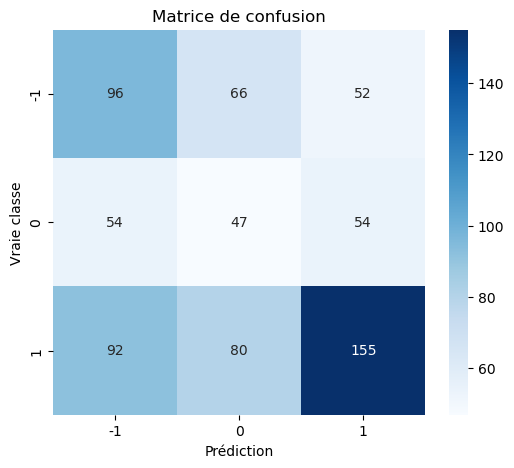

In [87]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_boost_original, y_test_boost_pred_original, labels=[-1, 0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[-1, 0, 1],
    yticklabels=[-1, 0, 1]
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion")
plt.show()

regression logistique

In [98]:
y_train.value_counts()

target_result
 1    1310
-1     855
 0     619
Name: count, dtype: int64

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


model = LogisticRegression(
    l1_ratio=0,
    max_iter=1000,
    class_weight="balanced"
)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_log = GridSearchCV(
    model,
    param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Meilleur C :", grid_log.best_params_["C"])
print("Accuracy CV :", grid_log.best_score_)

Meilleur C : 0.001
Accuracy CV : 0.46624194360848836


In [105]:
from sklearn.metrics import accuracy_score

y_test_pred = grid_log.predict(X_test)

acc = accuracy_score(y_test, y_test_pred)

print(acc)

0.4454022988505747


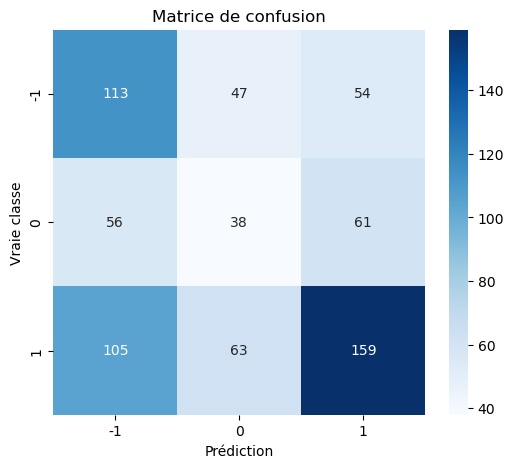

In [106]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred, labels=[-1, 0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[-1, 0, 1],
    yticklabels=[-1, 0, 1]
)

plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.title("Matrice de confusion")
plt.show()

Etude dataset d'entrainement

In [109]:
X.describe()

,team_1_player_1_note,team_1_player_2_note,team_1_player_3_note,team_1_player_4_note,team_1_player_5_note,team_1_player_6_note,team_1_player_7_note,team_1_player_8_note,team_1_player_9_note,team_1_player_10_note,team_1_player_11_note,team_2_player_1_note,team_2_player_2_note,team_2_player_3_note,team_2_player_4_note,team_2_player_5_note,team_2_player_6_note,team_2_player_7_note,team_2_player_8_note,team_2_player_9_note,team_2_player_10_note,team_2_player_11_note
count,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.000000,3480.00000,3480.000000,3480.000000,3480.000000
mean,59.144598,63.417672,65.564569,66.580718,67.098477,67.180920,67.325546,67.401437,68.240029,68.269253,67.777586,59.279770,63.226466,65.215115,66.508391,67.152902,66.915862,67.322874,67.62250,67.971322,68.177845,67.784741
std,15.401620,13.209076,11.982316,11.245714,10.757825,10.956318,10.780440,10.425118,8.741797,8.129452,7.680354,15.191334,13.364626,12.234898,11.316938,10.781352,11.090468,10.345870,10.13409,9.314842,8.179493,7.467815
min,23.700000,24.200000,24.200000,21.900000,21.900000,23.000000,22.200000,23.200000,23.000000,23.200000,22.300000,23.700000,24.200000,24.200000,23.200000,21.900000,23.000000,23.200000,23.00000,23.200000,23.200000,22.300000
25%,39.375000,61.300000,63.600000,64.800000,65.200000,65.200000,65.500000,65.400000,65.600000,64.900000,64.100000,40.200000,60.800000,63.100000,64.900000,65.100000,65.100000,65.400000,65.70000,65.100000,64.700000,64.300000
50%,65.800000,68.200000,69.000000,69.500000,69.700000,69.700000,69.800000,69.700000,69.900000,69.500000,68.600000,65.800000,68.000000,68.900000,69.400000,69.700000,69.600000,69.500000,69.75000,69.800000,69.500000,68.500000
75%,70.700000,72.000000,72.600000,72.900000,72.900000,73.200000,73.000000,72.900000,72.900000,73.100000,72.600000,70.400000,72.000000,72.400000,73.000000,72.900000,73.000000,72.900000,72.70000,73.000000,72.900000,72.500000
max,79.000000,82.500000,82.800000,82.800000,82.800000,82.800000,82.800000,82.800000,82.800000,82.800000,82.600000,82.500000,82.800000,82.800000,82.800000,82.800000,82.800000,82.800000,82.80000,82.800000,82.600000,82.600000


In [112]:
min_mean = X.mean().min()
print(f"{min_mean:.2f}")
max_mean = X.mean().max()
print(f"{max_mean:.2f}")

59.14
68.27


In [114]:
print(y.value_counts())
print()
print(y.value_counts()/len(y))

target_result
 1    1637
-1    1069
 0     774
Name: count, dtype: int64

target_result
 1    0.470402
-1    0.307184
 0    0.222414
Name: count, dtype: float64


In [124]:
import os
from pathlib import Path
import getpass
from dotenv import load_dotenv

# Load a repo-level .env when present (handy for local dev and batch runs).
for parent in [Path.cwd(), *Path.cwd().parents]:
    env_file = parent / ".env"
    if env_file.is_file():
        load_dotenv(env_file,override=True)
        break


In [127]:
X_train.to_csv(
    'X_train_dataset.csv',
    index=False,      # ne pas écrire l'index
    sep=';',          # séparateur ; (souvent utilisé en France)
    encoding='utf-8'  # encodage
)

y_train.to_csv(
    'y_train_dataset.csv',
    index=False,      # ne pas écrire l'index
    sep=';',          # séparateur ; (souvent utilisé en France)
    encoding='utf-8'  # encodage
)

X_test.to_csv(
    'X_test_dataset.csv',
    index=False,      # ne pas écrire l'index
    sep=';',          # séparateur ; (souvent utilisé en France)
    encoding='utf-8'  # encodage
)

y_test.to_csv(
    'y_test_dataset.csv',
    index=False,      # ne pas écrire l'index
    sep=';',          # séparateur ; (souvent utilisé en France)
    encoding='utf-8'  # encodage
)

In [126]:
import mlflow
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Set your variables for your environment
EXPERIMENT_NAME="jedha-football-predictor"

# Set tracking URI to your Hugging Face application
mlflow.set_tracking_uri(os.environ["APP_URI"])

# Set experiment's info
mlflow.set_experiment(EXPERIMENT_NAME)

# Get our experiment info
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# Call mlflow autolog
mlflow.sklearn.autolog()

with mlflow.start_run(experiment_id = experiment.experiment_id):
    # Perform grid search
    print("Grid search...")
    classifier = RandomForestClassifier(class_weight="balanced")

    # Grid of values to be tested
    params = {
        "max_depth": [2, 4, 6, 8, 10],
        "min_samples_leaf": [1, 2, 5],
        "min_samples_split": [2, 4, 8],
        "n_estimators": [10, 20, 40, 60, 80, 100]

    }
    gridsearch = GridSearchCV(
            classifier, param_grid=params
        )  
    gridsearch.fit(X_train, y_train)
    print("...Done.")
    print("Best hyperparameters : ", gridsearch.best_params_)
    print("Best validation accuracy : ", gridsearch.best_score_)

    predicted_qualities = gridsearch.predict(X_test.values)
    accuracy = gridsearch.score(X_test.values, y_test.values)

    # Print results
    print("RandomForestClassifier model")
    print("Accuracy: {}".format(accuracy))

2026/07/24 15:41:02 INFO mlflow.tracking.fluent: Experiment with name 'jedha-football-predictor' does not exist. Creating a new experiment.


Grid search...


2026/07/24 15:51:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/fidda/miniconda3/envs/football-team-predict/lib/python3.13/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(
2026/07/24 15:51:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: 

🏃 View run hilarious-wasp-739 at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16/runs/53c9aa37bd714ae990c94f6a30d34a56
🧪 View experiment at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16
🏃 View run industrious-pig-295 at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16/runs/4d0a2412176e41a4b207b53b80794b93
🧪 View experiment at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16
🏃 View run overjoyed-gull-84 at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16/runs/25fc7ea085d44c72825b275ba7009649
🧪 View experiment at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16
🏃 View run able-bear-652 at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16/runs/18442ce0d8964f11a866649028089367
🧪 View experiment at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16
🏃 View run rare-finch-678 at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16/runs/8b098a7b29474a47b061c223c8d

/home/fidda/miniconda3/envs/football-team-predict/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/fidda/miniconda3/envs/football-team-predict/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


RandomForestClassifier model
Accuracy: 0.4367816091954023
🏃 View run vaunted-lark-765 at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16/runs/94cac34d3ae341919bd9e75bc2f16717
🧪 View experiment at: https://franckidda-my-mlflow-tracker.hf.space/#/experiments/16


In [ ]:
predicted_qualities_serie = pd.Series(predicted_qualities, name="target_result_predicted")
predicted_qualities_serie.to_csv(
    'y_test_predicted_dataset.csv',
    index=False,      # ne pas écrire l'index
    sep=';',          # séparateur ; (souvent utilisé en France)
    encoding='utf-8'  # encodage
)